# Disaster Tweet Classification with TF-IDF and Logistic Regression

This notebook builds a simple NLP model that predicts whether a tweet is about a real disaster. We will use only the `text` column, convert the text into TF-IDF features, and train a logistic regression classifier.

## 1. Import the necessary libraries

We use `pandas` for working with tables, `matplotlib` and `seaborn` for plots, and `scikit-learn` for splitting the data, converting text into numbers, training the model, and evaluating predictions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TfidfVectorizer converts text into numerical features that a model can use.
from sklearn.feature_extraction.text import TfidfVectorizer

# LogisticRegression is a simple and strong baseline for binary classification.
from sklearn.linear_model import LogisticRegression

# train_test_split creates separate training and validation datasets.
from sklearn.model_selection import train_test_split

# These metrics help us understand how well the model predicts disaster tweets.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# This gives the charts a clean style.
sns.set_theme(style="whitegrid")

## 2. Load `train.csv` and `test.csv`

The training file contains labelled tweets, so it includes the `target` column. The test file does not include `target`; we will predict it at the end.

In [2]:
# Read the CSV files into pandas DataFrames.
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

## 3. Brief data exploration

Before training a model, it is useful to look at the data size, missing values, and the balance between disaster and non-disaster tweets.

In [3]:
# Display the first five rows of the labelled training data.
print("First five rows of train_data:")
display(train_data.head())

# Display the first five rows of the unlabelled test data.
print("First five rows of test_data:")
display(test_data.head())

First five rows of train_data:


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


First five rows of test_data:


,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [4]:
# The shape tells us the number of rows and columns in each dataset.
print("Training data shape:", train_data.shape)
print("Test data shape:", test_data.shape)

Training data shape: (7613, 5)
Test data shape: (3263, 4)


In [5]:
# Count missing values in each column.
print("Missing values in train_data:")
display(train_data.isna().sum().to_frame(name="missing_values"))

print("Missing values in test_data:")
display(test_data.isna().sum().to_frame(name="missing_values"))

Missing values in train_data:


,missing_values
id,0
keyword,61
location,2533
text,0
target,0


Missing values in test_data:


,missing_values
id,0
keyword,26
location,1105
text,0


In [6]:
# Count how many tweets belong to each class.
target_counts = train_data["target"].value_counts().sort_index()

# Calculate the proportion of tweets in each class.
target_proportions = train_data["target"].value_counts(normalize=True).sort_index()

# Combine counts and proportions into one easy-to-read table.
target_summary = pd.DataFrame({
    "count": target_counts,
    "proportion": target_proportions,
})

target_summary.index = ["Not Disaster (0)", "Disaster (1)"]
target_summary

,count,proportion
Not Disaster (0),4342,0.57034
Disaster (1),3271,0.42966


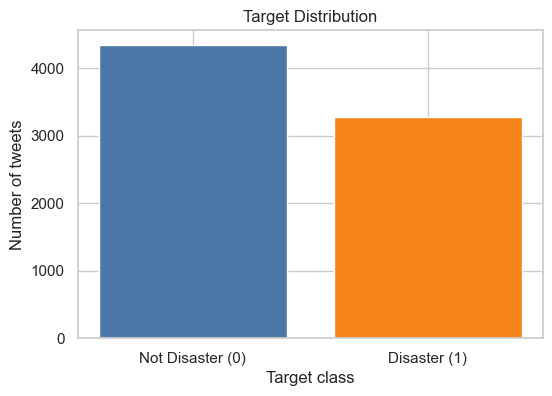

In [7]:
# Plot the number of tweets in each target class.
plt.figure(figsize=(6, 4))
plt.bar(target_summary.index, target_summary["count"], color=["#4C78A8", "#F58518"])
plt.title("Target Distribution")
plt.xlabel("Target class")
plt.ylabel("Number of tweets")
plt.xticks(rotation=0)
plt.show()

## 4. Prepare the data

We use only the `text` column as the model input and the `target` column as the label. The labelled data is split into 80% training data and 20% validation data.

`stratify=y` means the train and validation sets keep about the same proportion of disaster and non-disaster tweets as the original dataset. This makes the validation set more representative.

In [8]:
# X contains the text that the model will read.
X = train_data["text"]

# y contains the correct answer for each tweet.
y = train_data["target"]

# Split the labelled data into training and validation sets.
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X_train shape: (6090,)
X_val shape: (1523,)
y_train shape: (6090,)
y_val shape: (1523,)


## 5. Convert text into numerical features with TF-IDF

Machine learning models cannot directly learn from raw words, so we need to turn each tweet into numbers.

TF-IDF stands for term frequency-inverse document frequency. In plain language, it gives higher values to words or short phrases that are common in one tweet but not too common across all tweets. This helps the model focus on words that may be more useful for telling disaster tweets apart from non-disaster tweets.

In [9]:
# Create the TF-IDF vectorizer.
# max_features keeps the 5,000 most useful words or short phrases.
# ngram_range=(1, 2) uses single words and two-word phrases.
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
)

# Fit only on the training text so the model does not learn from validation or test data early.
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform the validation text using the vocabulary learned from the training text.
X_val_tfidf = vectorizer.transform(X_val)

# Transform the test text in the same way.
X_test_tfidf = vectorizer.transform(test_data["text"])

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (6090, 5000)
Validation TF-IDF shape: (1523, 5000)
Test TF-IDF shape: (3263, 5000)


## 6. Train a logistic regression classifier

Logistic regression can be used for binary text classification because it learns how strongly each TF-IDF feature points toward class `0` or class `1`. It then returns a probability for the positive class, which is `Disaster` in this project.

In [10]:
# Create the classifier.
# max_iter gives the model enough steps to finish training on this text data.
model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model on the training TF-IDF features and labels.
model.fit(X_train_tfidf, y_train)

/Users/tianfeng/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/tianfeng/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/tianfeng/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)


LogisticRegression(max_iter=1000, random_state=42)

## 7. Evaluate the validation predictions

The validation set contains labelled tweets that the model did not train on. This gives us a better idea of how the model may perform on new tweets.

In [11]:
# Predict class labels for the validation tweets.
y_val_pred = model.predict(X_val_tfidf)

# Calculate the main evaluation metrics.
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

# Show the metrics in a small table.
metrics_summary = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1 score"],
    "score": [accuracy, precision, recall, f1],
})

metrics_summary

,metric,score
0,Accuracy,0.818122
1,Precision,0.837209
2,Recall,0.715596
3,F1 score,0.771641


In [12]:
# The classification report shows precision, recall, and F1 score for both classes.
print(classification_report(
    y_val,
    y_val_pred,
    target_names=["Not Disaster", "Disaster"],
))

              precision    recall  f1-score   support

Not Disaster       0.81      0.90      0.85       869
    Disaster       0.84      0.72      0.77       654

    accuracy                           0.82      1523
   macro avg       0.82      0.81      0.81      1523
weighted avg       0.82      0.82      0.82      1523



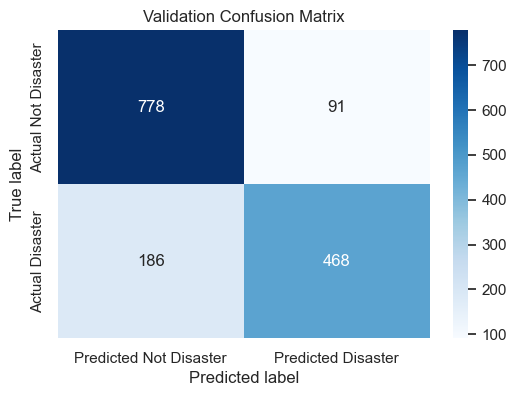

,Predicted Not Disaster,Predicted Disaster
Actual Not Disaster,778,91
Actual Disaster,186,468


In [13]:
# The confusion matrix compares the true labels with the predicted labels.
cm = confusion_matrix(y_val, y_val_pred)

# Put the confusion matrix into a labelled table before plotting it.
cm_df = pd.DataFrame(
    cm,
    index=["Actual Not Disaster", "Actual Disaster"],
    columns=["Predicted Not Disaster", "Predicted Disaster"],
)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Validation Confusion Matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()

cm_df

## Short conclusion

The model is a simple baseline, but the validation metrics above show that TF-IDF plus logistic regression can already learn useful patterns from tweet text.

- Accuracy means the share of validation tweets classified correctly.
- Precision means that when the model predicts `Disaster`, it is checking how often that prediction is correct.
- Recall means that among all real disaster tweets, it is checking how many the model successfully finds.
- F1 score combines precision and recall into one score, which is useful when both false alarms and missed disasters matter.

In [14]:
# Print the validation results in a short sentence.
print(
    f"Validation performance: accuracy={accuracy:.3f}, "
    f"precision={precision:.3f}, recall={recall:.3f}, F1={f1:.3f}."
)

Validation performance: accuracy=0.818, precision=0.837, recall=0.716, F1=0.772.


## 8. Explain the four confusion-matrix outcomes

- True negative: the tweet is not about a real disaster, and the model predicts `Not Disaster`.
- False positive: the tweet is not about a real disaster, but the model predicts `Disaster`.
- False negative: the tweet is about a real disaster, but the model predicts `Not Disaster`.
- True positive: the tweet is about a real disaster, and the model predicts `Disaster`.

## 9. Try a few new tweet predictions

You can edit the list below and add your own tweets. The predicted probability is the model's estimated probability that the tweet is a real disaster.

In [15]:
# Change or add tweets in this list to try your own examples.
new_tweets = [
    "Massive flooding has forced families to evacuate their homes tonight.",
    "I am on fire after that workout, best gym session ever!",
    "Earthquake reported downtown, emergency crews are responding.",
    "My phone battery just died and now my day is ruined.",
]

# Convert the new tweets using the same TF-IDF vectorizer from training.
new_tweets_tfidf = vectorizer.transform(new_tweets)

# Predict 0 or 1 for each new tweet.
new_predictions = model.predict(new_tweets_tfidf)

# Get the probability of class 1, which means Disaster.
new_probabilities = model.predict_proba(new_tweets_tfidf)[:, 1]

# Put the predictions into a readable table.
example_predictions = pd.DataFrame({
    "original_tweet": new_tweets,
    "predicted_class": new_predictions,
    "prediction_label": ["Disaster" if prediction == 1 else "Not Disaster" for prediction in new_predictions],
    "predicted_probability": new_probabilities.round(3),
})

example_predictions

,original_tweet,predicted_class,prediction_label,predicted_probability
0,Massive flooding has forced families to evacua...,1,Disaster,0.809
1,"I am on fire after that workout, best gym sess...",0,Not Disaster,0.190
2,"Earthquake reported downtown, emergency crews ...",1,Disaster,0.767
3,My phone battery just died and now my day is r...,0,Not Disaster,0.205


## 10. Predict the test dataset and create `submission.csv`

The final step is to predict the labels for `test.csv` and save a submission file with only the `id` and `target` columns.

In [16]:
# Predict the target class for every tweet in test.csv.
test_predictions = model.predict(X_test_tfidf)

# Create the submission table in the required format.
submission = pd.DataFrame({
    "id": test_data["id"],
    "target": test_predictions,
})

# Save the predictions to a CSV file.
submission.to_csv("submission.csv", index=False)

print("Saved submission.csv with shape:", submission.shape)
submission.head()

Saved submission.csv with shape: (3263, 2)


,id,target
0,0,1
1,2,1
2,3,1
3,9,0
4,11,1
